# 03 - The structure of my taste

Two unsupervised lenses on the same listening history:

- **Part A - Listening modes.** Group my *sessions* into recurring behavioural "modes"
  (deep dives, restless shuffling, background) with K-means.
- **Part B - Artist2Vec.** Place my *artists* in a learned vector space with word2vec - the
  trick Spotify uses for recs - for smoother recommendations, "taste blends", and a 2D map.

No labels in either part; the structure falls out of the behaviour itself.

In [1]:
import sys
from pathlib import Path

# Make the local package importable without `pip install -e .`
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "scripts" / "helper_scripts.py").exists():
        sys.path.insert(0, str(_p / "scripts"))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = ["DejaVu Sans", "Meiryo"]  # CJK fallback for non-Latin artist names
GREEN = "#1DB954"
pd.set_option("display.max_columns", 40)

from helper_scripts import load_streams, clean_streams

df = clean_streams(load_streams())
print(f"{len(df):,} streams loaded:", df["ts"].min().date(), "->", df["ts"].max().date())

172,078 streams loaded: 2019-04-09 -> 2026-04-12


## Part A - My listening modes (clustering)

A session (consecutive plays, <30 min gaps) is a little behavioural unit: how long, how
varied, how much I skipped, when it happened. I describe each session with those features
and let K-means find the recurring *shapes*. I pick the number of clusters with the
silhouette score and read the centroids to characterise each mode.

### A1. Streams → sessions → session features

Kept to sessions of at least 3 tracks so the features are meaningful.

In [2]:
d = df[df["is_track"]].copy().sort_values("ts").reset_index(drop=True)
gap = d["ts"].diff().dt.total_seconds().fillna(1e9)
d["session_id"] = (gap > 30 * 60).cumsum()

jst = d["ts"].dt.tz_convert("Asia/Tokyo")
d["hour"] = jst.dt.hour
d["weekday"] = jst.dt.dayofweek
for c in ["shuffle", "skipped", "offline"]:
    d[c] = d[c].astype("boolean").fillna(False).astype(int)

g = d.groupby("session_id")
sess = pd.DataFrame({
    "n_tracks": g.size(),
    "minutes": g["minutes"].sum(),
    "n_artists": g["artist"].nunique(),
    "skip_rate": g["skipped"].mean(),
    "shuffle_share": g["shuffle"].mean(),
    "offline_share": g["offline"].mean(),
    "start_hour": g["hour"].first(),
    "weekday": g["weekday"].first(),
    "start_ts": g["ts"].first(),
})
sess["artist_diversity"] = sess["n_artists"] / sess["n_tracks"]
sess["weekend"] = (sess["weekday"] >= 5).astype(int)
sess = sess[sess["n_tracks"] >= 3].copy()
print(f"{len(sess):,} sessions with >= 3 tracks")
sess.head()

7,299 sessions with >= 3 tracks


,n_tracks,minutes,n_artists,skip_rate,shuffle_share,offline_share,start_hour,weekday,start_ts,artist_diversity,weekend
session_id,,,,,,,,,,,
1,14,18.598583,9,0.0,0.50000,0.0,15,1,2019-04-09 06:50:06+00:00,0.642857,0
2,41,101.640933,13,0.0,0.02439,0.0,16,1,2019-04-09 07:48:58+00:00,0.317073,0
3,17,21.350183,3,0.0,0.00000,0.0,19,1,2019-04-09 10:37:37+00:00,0.176471,0
4,40,77.552383,15,0.0,0.05000,0.0,23,1,2019-04-09 14:22:25+00:00,0.375000,0
6,3,3.662317,1,0.0,0.00000,0.0,12,2,2019-04-10 03:57:00+00:00,0.333333,0


### A2. Scale features & choose k

Counts (`n_tracks`, `minutes`) are skewed, so I log them; the start hour is cyclical, so
it's encoded as sin/cos (23:00 and 00:00 should be close). Then standardize and sweep k,
keeping the one with the best average silhouette.

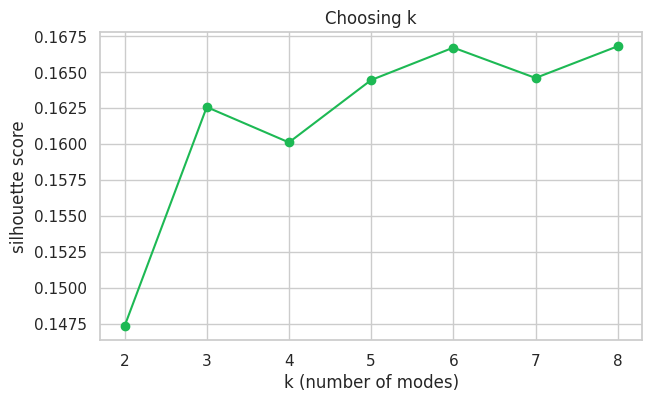

best k by silhouette: 8


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sess["hour_sin"] = np.sin(2 * np.pi * sess["start_hour"] / 24)
sess["hour_cos"] = np.cos(2 * np.pi * sess["start_hour"] / 24)

feats = ["n_tracks", "minutes", "artist_diversity", "skip_rate",
         "shuffle_share", "offline_share", "hour_sin", "hour_cos", "weekend"]
X = sess[feats].copy()
X["n_tracks"] = np.log1p(X["n_tracks"])
X["minutes"] = np.log1p(X["minutes"])
Xs = StandardScaler().fit_transform(X)

scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xs)
    scores[k] = silhouette_score(Xs, km.labels_, sample_size=5000, random_state=0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(scores), list(scores.values()), "o-", color=GREEN)
ax.set_xlabel("k (number of modes)"); ax.set_ylabel("silhouette score"); ax.set_title("Choosing k")
plt.show()
best_k = max(scores, key=scores.get)
print("best k by silhouette:", best_k)

### A3. Cluster & profile the modes

Fit K-means at the chosen k, then read each cluster's average session - its fingerprint.

In [4]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(Xs)
sess["mode"] = km.labels_

profile_cols = ["n_tracks", "minutes", "artist_diversity", "skip_rate",
                "shuffle_share", "offline_share", "start_hour", "weekend"]
profile = sess.groupby("mode")[profile_cols].mean()
profile.insert(0, "n_sessions", sess["mode"].value_counts().sort_index())
profile.round(2)

,n_sessions,n_tracks,minutes,artist_diversity,skip_rate,shuffle_share,offline_share,start_hour,weekend
mode,,,,,,,,,
0,1004,21.63,30.36,0.73,0.28,0.96,0.01,9.76,0.05
1,1310,8.18,12.35,0.78,0.04,0.98,0.01,16.15,0.00
2,797,7.37,9.05,0.80,0.27,0.94,0.00,14.59,1.00
3,907,41.04,60.85,0.59,0.16,0.92,0.01,15.93,1.00
4,962,16.87,15.12,0.85,0.76,0.93,0.01,16.05,0.03
5,816,12.24,22.12,0.60,0.28,0.11,0.00,14.77,0.24
6,1305,47.08,72.43,0.56,0.10,0.93,0.01,17.13,0.00
7,198,22.57,31.88,0.81,0.30,0.92,0.82,15.25,0.26


In [5]:
zfeat = ["n_tracks", "minutes", "artist_diversity", "skip_rate",
         "shuffle_share", "offline_share", "start_hour"]
z = (profile[zfeat] - profile[zfeat].mean()) / profile[zfeat].std()
for m in z.index:
    hi = z.loc[m].sort_values(ascending=False).head(2).index.tolist()
    lo = z.loc[m].sort_values().head(1).index.tolist()
    print(f"mode {m} (n={int(profile.loc[m, 'n_sessions']):,}): high {hi} | low {lo}")

mode 0 (n=1,004): high ['shuffle_share', 'artist_diversity'] | low ['start_hour']
mode 1 (n=1,310): high ['artist_diversity', 'start_hour'] | low ['skip_rate']
mode 2 (n=797): high ['artist_diversity', 'shuffle_share'] | low ['n_tracks']
mode 3 (n=907): high ['n_tracks', 'minutes'] | low ['artist_diversity']
mode 4 (n=962): high ['skip_rate', 'artist_diversity'] | low ['minutes']
mode 5 (n=816): high ['skip_rate', 'start_hour'] | low ['shuffle_share']
mode 6 (n=1,305): high ['minutes', 'n_tracks'] | low ['artist_diversity']
mode 7 (n=198): high ['offline_share', 'artist_diversity'] | low ['minutes']


### A4. Visualize the modes

A heatmap of standardized centroids (green = above my average session) makes the
fingerprints comparable; a 2D PCA scatter shows how separated the modes are.

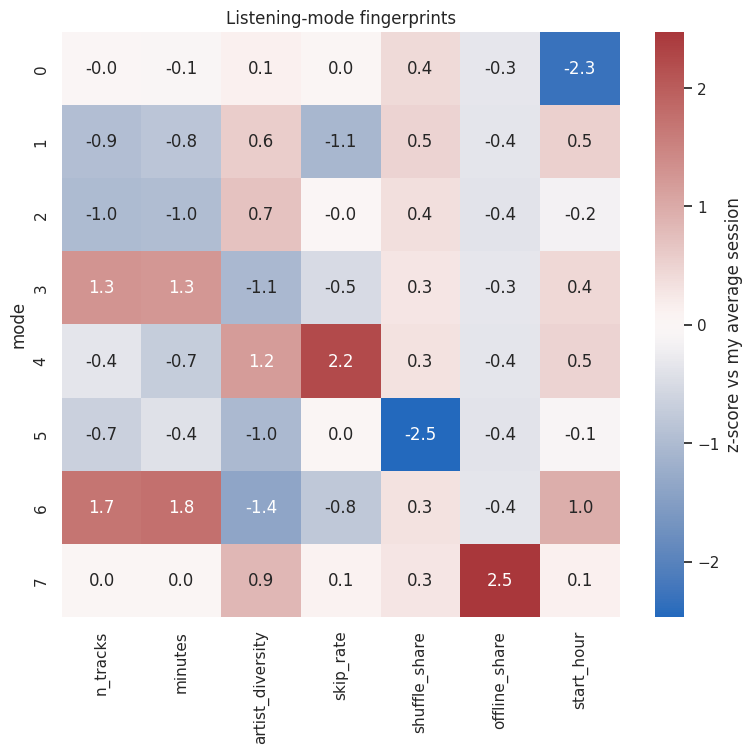

In [6]:
fig, ax = plt.subplots(figsize=(9, 0.7 * len(z) + 2))
sns.heatmap(z, annot=True, fmt=".1f", cmap="vlag", center=0, ax=ax,
            cbar_kws={"label": "z-score vs my average session"})
ax.set_title("Listening-mode fingerprints"); ax.set_ylabel("mode")
plt.show()

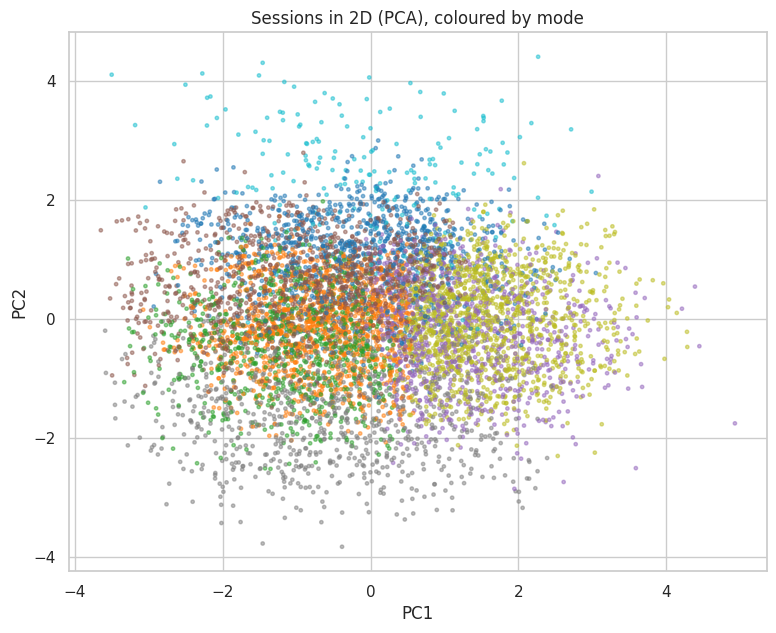

In [7]:
from sklearn.decomposition import PCA
p2 = PCA(n_components=2, random_state=0).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(p2[:, 0], p2[:, 1], c=sess["mode"], cmap="tab10", s=6, alpha=0.5)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Sessions in 2D (PCA), coloured by mode")
plt.show()

### A5. How my listening modes shifted over the years

Does a particular mode take over as time goes on? (Ties back to the rising skip rate.)

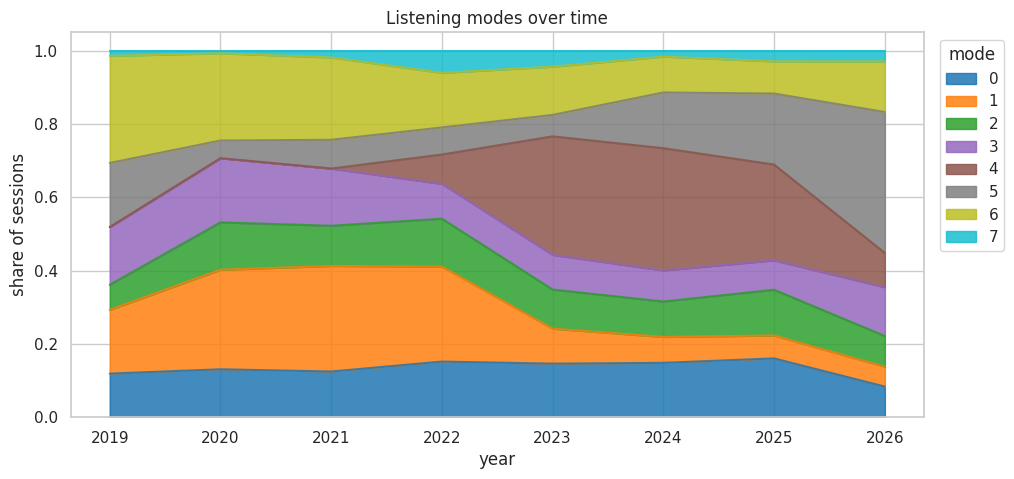

In [8]:
sess["year"] = sess["start_ts"].dt.year
share = sess.groupby(["year", "mode"]).size().unstack(fill_value=0)
share = share.div(share.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(11, 5))
share.plot.area(ax=ax, cmap="tab10", alpha=0.85)
ax.set_ylabel("share of sessions"); ax.set_xlabel("year")
ax.set_title("Listening modes over time")
ax.legend(title="mode", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()

## Part B - Artist2Vec (embeddings)

Clustering grouped *sessions*; now I embed *artists*. Treat each session as a "sentence"
and each artist as a "word", and **word2vec** places artists that appear in similar
contexts close together in a 64-D space. That gives smoother neighbours than raw
co-occurrence, recommendations via vector math, and a 2D taste map.

### B1. Sessions as sentences

In [9]:
d = df[df["is_track"]].dropna(subset=["artist"]).copy().sort_values("ts").reset_index(drop=True)
gap = d["ts"].diff().dt.total_seconds().fillna(1e9)
d["session_id"] = (gap > 30 * 60).cumsum()

sentences = d.groupby("session_id")["artist"].apply(list).tolist()
print(f"{len(sentences):,} sessions (sentences) | {d['artist'].nunique():,} distinct artists")
print("example:", sentences[0][:6])

10,847 sessions (sentences) | 4,603 distinct artists
example: ['Modest Mouse', 'Many Rooms', 'Cemeteries', 'Modern Baseball', "Panucci's Pizza", 'Elvis Depressedly']


### B2. Train word2vec

Skip-gram, 64-dim vectors, context window 5. `min_count=20` keeps artists I've actually
played a fair bit (`workers=1` + `seed` for reproducibility).

In [10]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences, vector_size=64, window=5, min_count=20,
    sg=1, negative=10, epochs=30, workers=1, seed=1,
)
print("embedded artists (>= 20 plays):", len(model.wv))

embedded artists (>= 20 plays): 918


### B3. Nearest neighbours

Cosine-nearest artists in embedding space - the recommender.

In [11]:
for seed in ["Radiohead", "Mac DeMarco", "Kendrick Lamar", "Bill Evans"]:
    if seed not in model.wv:
        continue
    print(f"{seed} ->")
    for a, s in model.wv.most_similar(seed, topn=8):
        print(f"   {s:.3f}  {a}")
    print()

Radiohead ->
   0.713  Pixies
   0.713  Oasis
   0.703  The Velvet Underground
   0.695  Led Zeppelin
   0.687  Ten Years After
   0.682  Sonic Youth
   0.654  Redbone
   0.633  Two Door Cinema Club

Mac DeMarco ->
   0.594  Brett Eldredge
   0.587  Smerz
   0.544  sign crushes motorist
   0.527  Led Zeppelin
   0.522  NIGHT TRAIN
   0.516  Michael Bublé
   0.515  Loving
   0.508  Sonic Youth

Kendrick Lamar ->
   0.602  Lil Yachty
   0.600  Desiigner
   0.598  Rich Brian
   0.591  Dr. Dre
   0.589  Smokepurpp
   0.589  Travis Scott
   0.579  Ski Mask The Slump God
   0.557  21 Savage

Bill Evans ->
   0.788  Bill Evans Trio
   0.766  Stan Getz
   0.649  Charles Mingus
   0.600  Cannonball Adderley
   0.588  Benjamine Hans
   0.588  Paul Desmond
   0.585  Wes Montgomery
   0.579  Duke Ellington



### B4. Taste blends (vector math)

word2vec vectors support arithmetic, so I can ask for artists that fit the *blend* of two
seeds at once - "if you like A **and** B, you'll probably like…".

In [12]:
blends = [["Radiohead", "Bill Evans"], ["Mac DeMarco", "Kendrick Lamar"], ["A$AP Rocky", "Beach House"]]
for pair in blends:
    pair = [p for p in pair if p in model.wv]
    if len(pair) < 2:
        continue
    print(f"{pair[0]}  +  {pair[1]} ->")
    for a, s in model.wv.most_similar(positive=pair, topn=6):
        print(f"   {s:.3f}  {a}")
    print()

Radiohead  +  Bill Evans ->
   0.730  The Velvet Underground
   0.720  Oasis
   0.705  Led Zeppelin
   0.704  Ten Years After
   0.696  Pixies
   0.676  Redbone

Mac DeMarco  +  Kendrick Lamar ->
   0.652  Rich Brian
   0.611  Lil Yachty
   0.579  Sonic Youth
   0.577  Ski Mask The Slump God
   0.573  Rihanna
   0.563  Oasis

A$AP Rocky  +  Beach House ->
   0.654  Cocteau Twins
   0.611  Current Joys
   0.562  Mazzy Star
   0.558  Slowdive
   0.555  Lil Yachty
   0.552  ScHoolboy Q



### B5. The taste map

Project the top artists' 64-D vectors to 2D with t-SNE; colour by a quick k-means on the
embeddings, size by minutes. Artists that sit together genuinely *sound together* in my
listening.

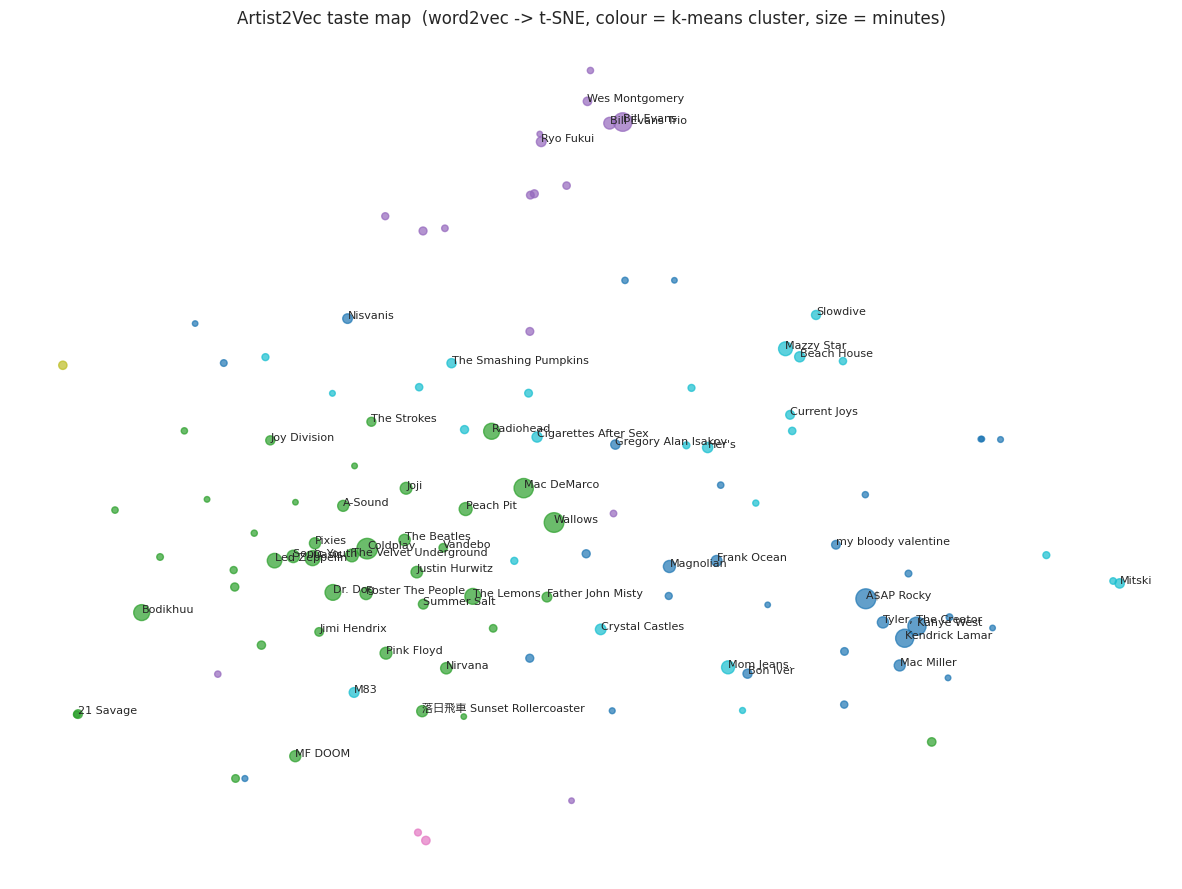

In [13]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

art_minutes = df[df["is_track"]].groupby("artist")["minutes"].sum()
top = [a for a in art_minutes.sort_values(ascending=False).index if a in model.wv][:120]
V = np.array([model.wv[a] for a in top])

labels = KMeans(n_clusters=6, n_init=10, random_state=0).fit_predict(V)
xy = TSNE(n_components=2, perplexity=15, init="pca", random_state=0).fit_transform(V)

fig, ax = plt.subplots(figsize=(15, 11))
ax.scatter(xy[:, 0], xy[:, 1], c=labels, cmap="tab10",
           s=[art_minutes[a] / 25 for a in top], alpha=0.7)
for i, a in enumerate(top[:55]):
    ax.text(xy[i, 0], xy[i, 1], a, fontsize=8)
ax.set_title("Artist2Vec taste map  (word2vec -> t-SNE, colour = k-means cluster, size = minutes)")
ax.axis("off")
plt.show()

## Takeaways

- My **sessions** fall into a few recurring modes (deep dive / restless shuffle /
  background), discovered with no labels - and the mode mix shifts over the years.
- My **artists** form musically sensible neighbourhoods straight from session behaviour;
  the taste-blend trick is a fun, genuinely useful recommendation primitive.
- Together with notebooks 01 (what/when/where) and 02 (what's predictable), this is a
  full picture of seven years of listening - from raw JSON to embeddings.

The taste blends are the part I keep playing with. Asking for the midpoint between two
artists I love is weirdly satisfying, and it usually lands on something I'd actually queue.
It's also a bit funny that a model fed nothing but "what I played next to what" quietly
rebuilds genre lines no one ever handed it.